# Comparison Delta Sigma Data Profiles
We will compare the difference when estimating the delta sigma profiles with different cosmologies to search for the galaxy sources around each cluster

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sacc

In [2]:
sacc_baseline = sacc.Sacc.load_fits("/sps/lsst/groups/clusters/cl_pipeline_project/TXPipe_data/cosmodc2/outputs-full-2026/cluster_sacc_catalog.sacc")
sacc_03 = sacc.Sacc.load_fits("/sps/lsst/groups/clusters/cl_pipeline_project/TXPipe_data/cosmodc2/outputs-cosmo-03-09/cluster_sacc_catalog.sacc")
sacc_04 = sacc.Sacc.load_fits("/sps/lsst/groups/clusters/cl_pipeline_project/TXPipe_data/cosmodc2/outputs-cosmo-04-08/cluster_sacc_catalog.sacc")

<>:68: SyntaxWarning: invalid escape sequence '\O'
<>:70: SyntaxWarning: invalid escape sequence '\O'
<>:72: SyntaxWarning: invalid escape sequence '\O'
<>:68: SyntaxWarning: invalid escape sequence '\O'
<>:70: SyntaxWarning: invalid escape sequence '\O'
<>:72: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_13439/2130136712.py:68: SyntaxWarning: invalid escape sequence '\O'
  label=f"$\Omega_c = 0.22$" if is_first else None)
/tmp/ipykernel_13439/2130136712.py:70: SyntaxWarning: invalid escape sequence '\O'
  label=f"$\Omega_c = 0.3$"  if is_first else None)
/tmp/ipykernel_13439/2130136712.py:72: SyntaxWarning: invalid escape sequence '\O'
  label=f"$\Omega_c = 0.4$"  if is_first else None)


a
[-1.35087347  7.41435219  0.74888888  2.57901319  1.28868672 -6.18466184
  9.29523077] [-1.3860847   2.39604485 -0.42160497  1.12782109  6.17595907 -3.22451866
  0.01914397]
[ 6.24207749 -0.220828    6.04137236 -2.73403936  9.74208803 -1.96676224
  2.26689593] [ 9.40879238 -4.35792592  0.16876764  2.30621766  2.4352029   1.61465308
 -3.16809272]
[ -3.39498109  16.34084639  -0.64790644   4.8337041   13.77363936
 -12.31895516   3.60005076] [-1.97234441  6.24306683 -0.58056873  5.39679052 -0.17457025 -0.46883129
 -9.06781836]
[-13.14742921   2.70034804  16.84495628  -0.86331461  -5.55510783
   3.78931892  10.21641912] [-1.49591418 -3.81256992  8.29547184  1.35902502 -3.20960021 -0.80722299
  9.85734486]
[ 12.58875867   5.13927656   6.27380342  -2.46923684   9.87233007
  28.31812226 -14.73964561] [ 2.06855838 10.66643317 -0.98231502 -5.19621166  9.06105105 10.11604693
 -0.62351238]
[ -8.19337687   5.0885213   36.37085094 -19.76713702  11.43623747
  -2.038377    22.29650561] [-9.39984756 

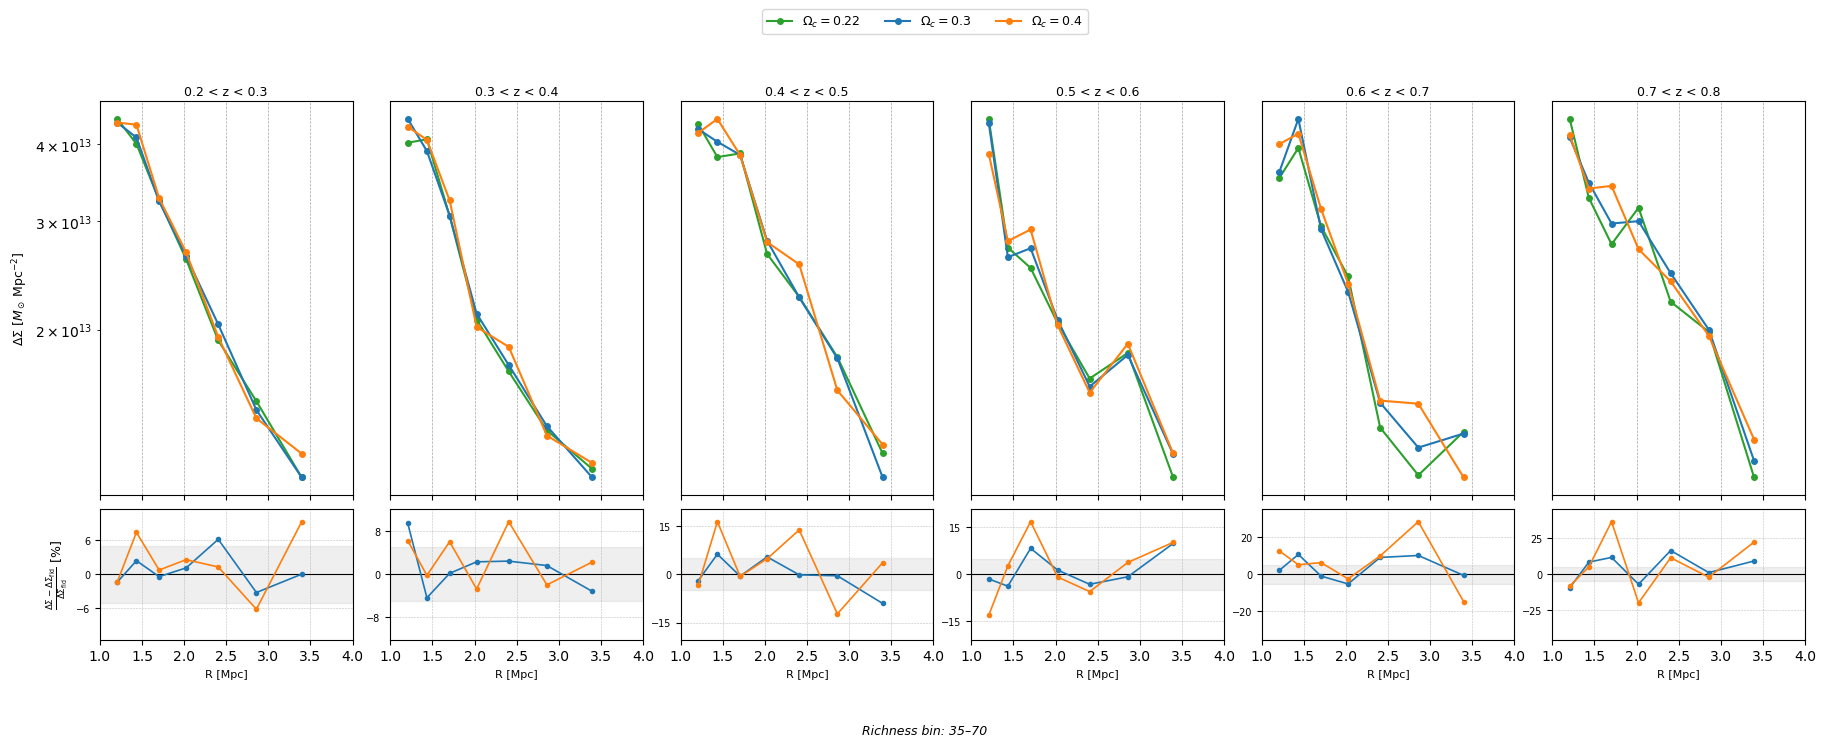

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Parameters ────────────────────────────────────────────────────────────────
N_Z_BINS = 6
N_R_BINS = 7
RICH_BIN = "bin_rich_1"

Z_LABELS = [
    "0.2 < z < 0.3", "0.3 < z < 0.4", "0.4 < z < 0.5",
    "0.5 < z < 0.6", "0.6 < z < 0.7", "0.7 < z < 0.8",
]

COLOR_BASE = "#2ca02c"
COLOR_03   = "#1f77b4"
COLOR_04   = "#ff7f0e"

# ── Collect data ──────────────────────────────────────────────────────────────
baseline_data = {i: [] for i in range(N_Z_BINS)}
data_03       = {i: [] for i in range(N_Z_BINS)}
data_04       = {i: [] for i in range(N_Z_BINS)}
radii         = {i: [] for i in range(N_Z_BINS)}

for i in range(N_Z_BINS):
    for j in range(N_R_BINS):
        z_bin      = f"bin_z_{i}"
        radius_bin = f"radius_{j}"
        trac = ('cosmodc2_redmapper', RICH_BIN, z_bin, radius_bin)
        dtype = sacc.data_types.standard_types.cluster_delta_sigma

        baseline_data[i].append(sacc_baseline.get_data_points(dtype, tracers=trac)[0].value)
        data_03[i].append(sacc_03.get_data_points(dtype, tracers=trac)[0].value)
        data_04[i].append(sacc_04.get_data_points(dtype, tracers=trac)[0].value)
        radii[i].append(sacc_baseline.get_tracer(name=radius_bin).center)

for i in range(N_Z_BINS):
    baseline_data[i] = np.array(baseline_data[i])
    data_03[i]       = np.array(data_03[i])
    data_04[i]       = np.array(data_04[i])
    radii[i]         = np.array(radii[i])

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 7))
gs  = gridspec.GridSpec(
    2, N_Z_BINS,
    height_ratios=[3, 1],
    hspace=0.05,
    wspace=0.15,
)

axes_main = [fig.add_subplot(gs[0, i]) for i in range(N_Z_BINS)]
axes_res  = [fig.add_subplot(gs[1, i]) for i in range(N_Z_BINS)]

# ── Plot ──────────────────────────────────────────────────────────────────────
for i in range(N_Z_BINS):
    ax   = axes_main[i]
    axr  = axes_res[i]
    R    = radii[i]
    base = baseline_data[i]
    d03  = data_03[i]
    d04  = data_04[i]

    is_first = (i == 0)

    # ── Main panel ───────────────────────────────────────────────────────
    ax.plot(R, base, 'o-', color=COLOR_BASE, lw=1.5, ms=4,
            label=f"$\Omega_c = 0.22$" if is_first else None)
    ax.plot(R, d03,  'o-', color=COLOR_03,   lw=1.5, ms=4,
            label=f"$\Omega_c = 0.3$"  if is_first else None)
    ax.plot(R, d04,  'o-', color=COLOR_04,   lw=1.5, ms=4,
            label=f"$\Omega_c = 0.4$"  if is_first else None)

    ax.set_yscale("log")
    ax.set_title(Z_LABELS[i], fontsize=9, pad=4)
    ax.set_xlim(1, 4)
    ax.tick_params(labelbottom=False, labelsize=8)


    ax.grid(True, which="major", ls="--", lw=0.5, alpha=0.7, color="gray")
    # ax.grid(True, which="minor", ls=":",  lw=0.6, alpha=0.7, color="gray")

    # Y-axis: ticks + label on the LEFT of the first subplot only
    if is_first:
        print("a")
        ax.yaxis.tick_left()
        ax.yaxis.set_label_position("left")
        ax.set_ylabel(r"$\Delta\Sigma\ [M_\odot\,\mathrm{Mpc}^{-2}]$", fontsize=9)
        ax.tick_params(axis="y", labelsize=8)
    else:
        ax.yaxis.set_visible(False)
# ── Residual panel — independent y-limit per subplot ─────────────────
    res_03 = (d03 - base) / base * 100
    res_04 = (d04 - base) / base * 100
    print(res_04, res_03)
    max_abs = np.nanmax(np.abs(np.concatenate([res_03, res_04])))
    ylim    = max_abs * 1.25

    axr.axhline(0, color="black", lw=0.8)
    axr.axhspan(-5, 5, color="gray", alpha=0.12)
    axr.plot(R, res_03, 'o-', color=COLOR_03, lw=1.2, ms=3)
    axr.plot(R, res_04, 'o-', color=COLOR_04, lw=1.2, ms=3)

    axr.set_xlim(1, 4)
    axr.set_ylim(-ylim, ylim)
    axr.set_xlabel("R [Mpc]", fontsize=8)
    axr.grid(True, which="major", ls="--", lw=0.4, alpha=0.5, color="gray")

    axr.yaxis.set_major_locator(plt.MaxNLocator(nbins=4, symmetric=True, integer=False, prune='both'))

    if is_first:
        axr.yaxis.tick_left()
        axr.yaxis.set_label_position("left")
        axr.tick_params(axis="y", labelsize=7)
        axr.set_ylabel(
            r"$\frac{\Delta\Sigma - \Delta\Sigma_\mathrm{fid}}{\Delta\Sigma_\mathrm{fid}}\ [\%]$",
            fontsize=9,
        )
    else:
        axr.tick_params(axis="y", labelsize=7)

# ── Legend & title ────────────────────────────────────────────────────────────
handles, labels = axes_main[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=3,
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle("Richness bin: 35–70", y=-0.01, fontsize=9, style="italic")

plt.savefig("./delta_sigma_cosmo_comparison.pdf", dpi=150, bbox_inches="tight")
plt.show()